# Public Industrial Automation Sales Analysis

This notebook analyzes anonymized order-performance data from 2024 through June 2026.

All customer names, employee names, and monetary amounts have been anonymized or converted into index values before publication.

In [1]:
import pandas as pd
from google.colab import files
from IPython.display import display


# Upload the 5 anonymized public CSV files
uploaded = files.upload()


expected_files = {
    "customer_summary_public.csv": [
        "rank",
        "customer_id",
        "total_value_index",
        "order_count_index",
        "domestic_share_pct",
        "overseas_share_pct"
    ],
    "customer_monthly_public.csv": [
        "year_month",
        "customer_id",
        "monthly_value_index"
    ],
    "employee_yearly_public.csv": [
        "employee_id",
        "year",
        "year_label",
        "order_value_index",
        "order_count_index"
    ],
    "employee_same_period_public.csv": [
        "employee_id",
        "year",
        "order_value_index",
        "order_count_index"
    ],
    "market_yearly_public.csv": [
        "year",
        "market_type",
        "share_pct"
    ]
}


missing_files = [
    file_name
    for file_name in expected_files
    if file_name not in uploaded
]

if missing_files:
    raise FileNotFoundError(
        f"Missing files: {missing_files}"
    )


data = {}

for file_name, required_columns in expected_files.items():
    frame = pd.read_csv(file_name)

    missing_columns = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{file_name} is missing columns: {missing_columns}"
        )

    data[file_name] = frame


customer_summary = data["customer_summary_public.csv"]
customer_monthly = data["customer_monthly_public.csv"]
employee_yearly = data["employee_yearly_public.csv"]
employee_same_period = data["employee_same_period_public.csv"]
market_yearly = data["market_yearly_public.csv"]


print("All 5 public files loaded successfully.\n")

for file_name, frame in data.items():
    print(
        f"{file_name}: "
        f"{frame.shape[0]} rows × {frame.shape[1]} columns"
    )


print("\nCustomer summary preview:")
display(customer_summary)

print("\nCustomer monthly preview:")
display(customer_monthly.head(10))

print("\nEmployee yearly preview:")
display(employee_yearly.head(15))

print("\nEmployee same-period preview:")
display(employee_same_period.head(15))

print("\nMarket yearly preview:")
display(market_yearly)


Saving customer_monthly_public.csv to customer_monthly_public.csv
Saving customer_summary_public.csv to customer_summary_public.csv
Saving employee_same_period_public.csv to employee_same_period_public.csv
Saving employee_yearly_public.csv to employee_yearly_public.csv
Saving market_yearly_public.csv to market_yearly_public.csv
All 5 public files loaded successfully.

customer_summary_public.csv: 5 rows × 6 columns
customer_monthly_public.csv: 32 rows × 3 columns
employee_yearly_public.csv: 20 rows × 5 columns
employee_same_period_public.csv: 19 rows × 4 columns
market_yearly_public.csv: 6 rows × 3 columns

Customer summary preview:


,rank,customer_id,total_value_index,order_count_index,domestic_share_pct,overseas_share_pct
0,1,Customer_01,100.000000,90.476190,100.000000,0.000000
1,2,Customer_02,89.043063,76.190476,100.000000,0.000000
2,3,Customer_03,79.616860,52.380952,0.000000,100.000000
3,4,Customer_04,75.692461,71.428571,100.000000,0.000000
4,5,Customer_05,73.560848,100.000000,13.489366,86.510634



Customer monthly preview:


,year_month,customer_id,monthly_value_index
0,2024-01,Customer_05,8.587586
1,2024-05,Customer_05,12.794491
2,2024-06,Customer_05,27.233914
3,2024-08,Customer_01,0.217822
4,2024-09,Customer_01,11.089109
5,2024-09,Customer_05,0.010874
6,2024-10,Customer_04,29.227723
7,2024-11,Customer_01,3.413861
8,2024-12,Customer_01,0.160396
9,2025-01,Customer_01,2.668911



Employee yearly preview:


,employee_id,year,year_label,order_value_index,order_count_index
0,Employee_01,2024,2024,49.069166,34.615385
1,Employee_01,2025,2025,100.000000,100.000000
2,Employee_01,2026,2026 YTD,79.779984,74.038462
3,Employee_02,2024,2024,36.786981,45.192308
4,Employee_02,2025,2025,48.824674,14.423077
5,Employee_03,2025,2025,16.280562,32.692308
6,Employee_03,2026,2026 YTD,40.491991,34.615385
7,Employee_04,2024,2024,13.387736,23.076923
8,Employee_04,2025,2025,16.544255,20.192308
9,Employee_04,2026,2026 YTD,17.050639,16.346154



Employee same-period preview:


,employee_id,year,order_value_index,order_count_index
0,Employee_01,2024,29.195099,19.480519
1,Employee_01,2025,61.733653,67.532468
2,Employee_01,2026,100.000000,100.000000
3,Employee_02,2024,32.084136,32.467532
4,Employee_02,2025,61.199153,19.480519
5,Employee_03,2025,0.493909,7.792208
6,Employee_03,2026,50.754574,46.753247
7,Employee_04,2024,8.952210,18.181818
8,Employee_04,2025,9.787103,16.883117
9,Employee_04,2026,21.372076,22.077922



Market yearly preview:


,year,market_type,share_pct
0,2024,Domestic,85.341748
1,2024,Overseas,14.658252
2,2025,Domestic,74.911762
3,2025,Overseas,25.088238
4,2026,Domestic,90.893392
5,2026,Overseas,9.106608


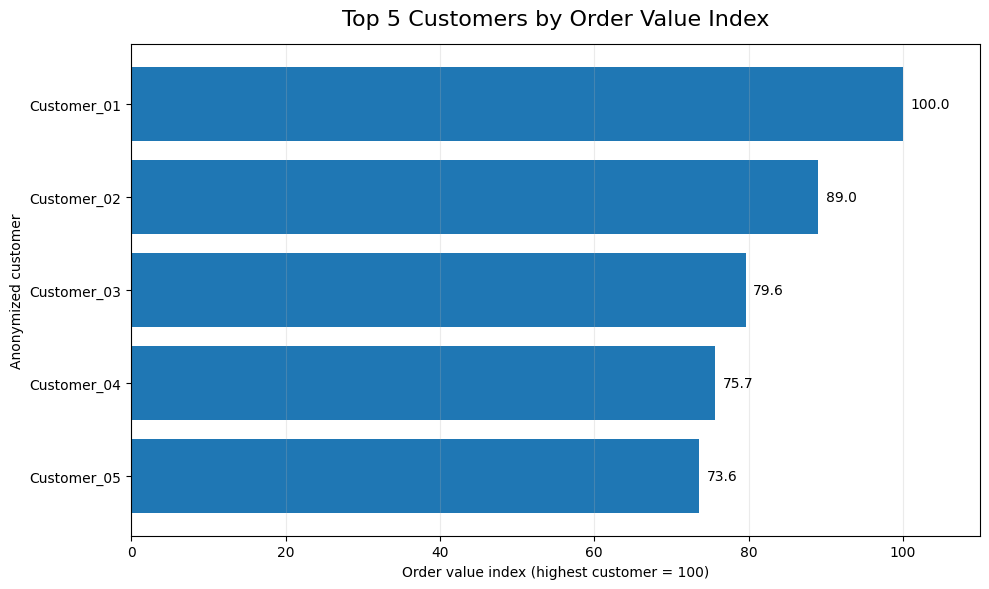

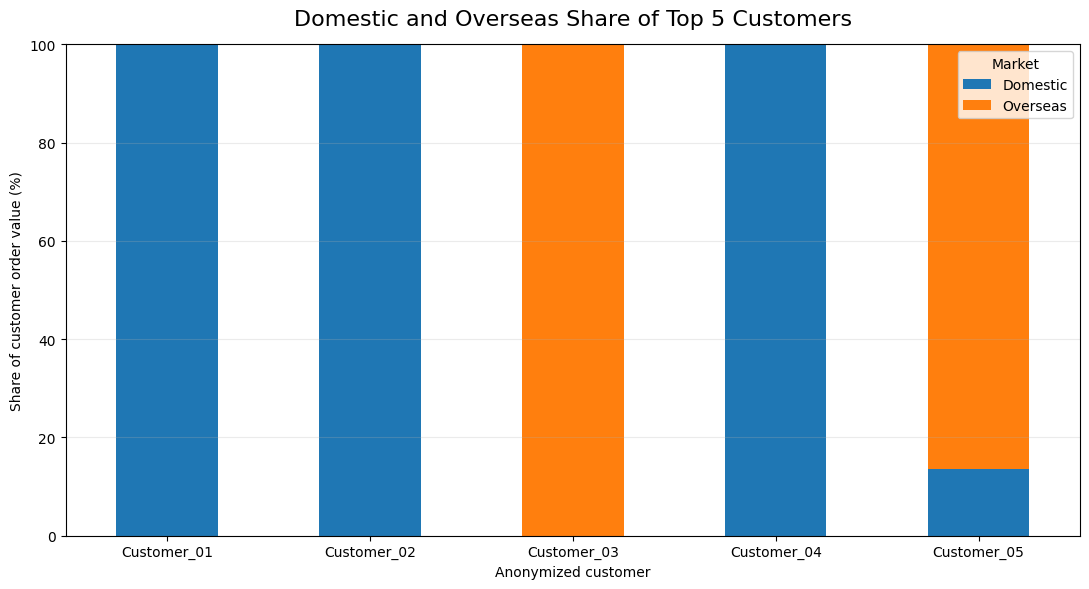

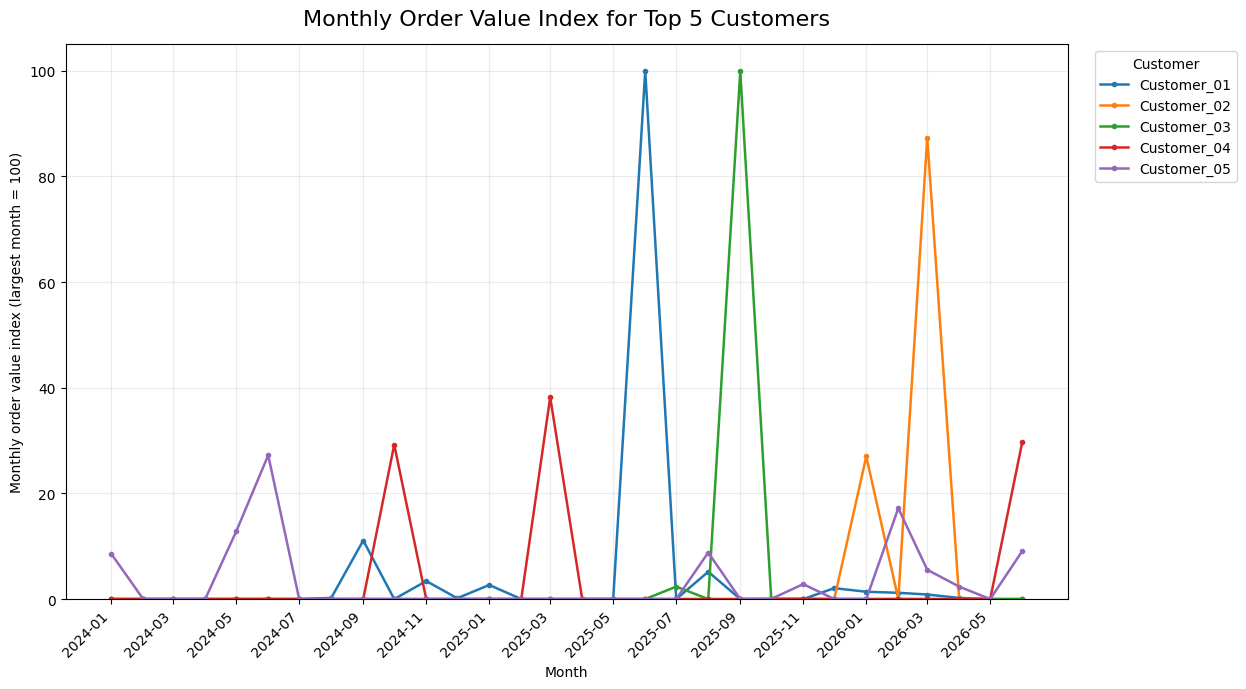

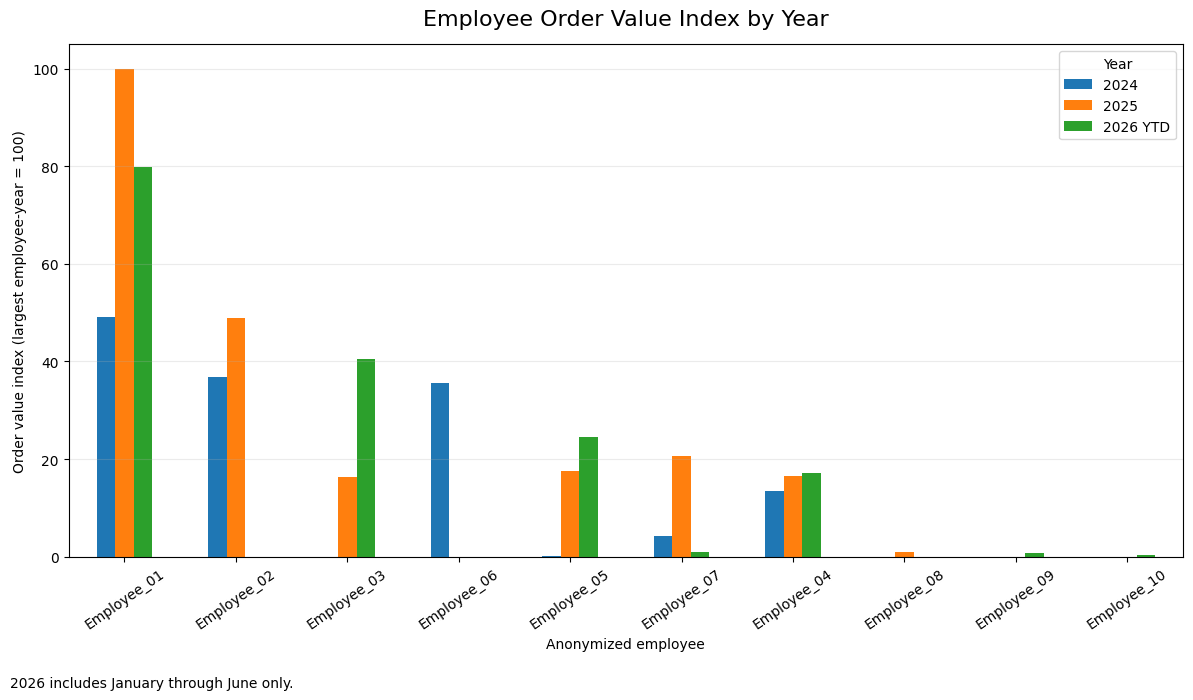

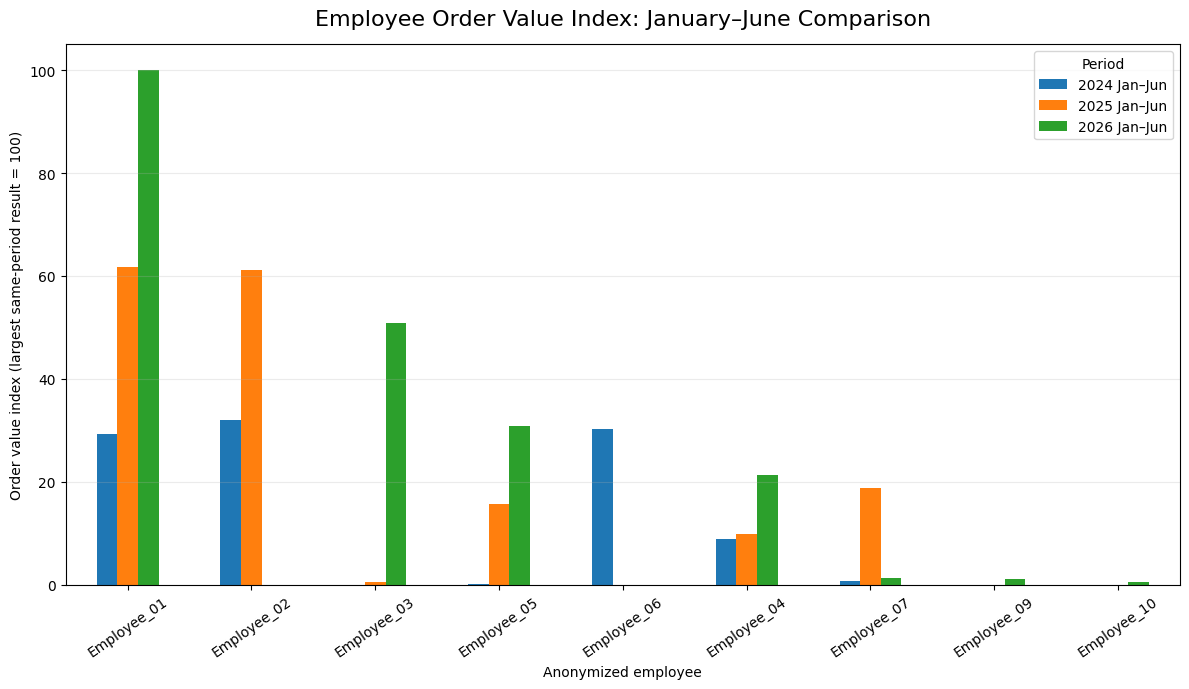

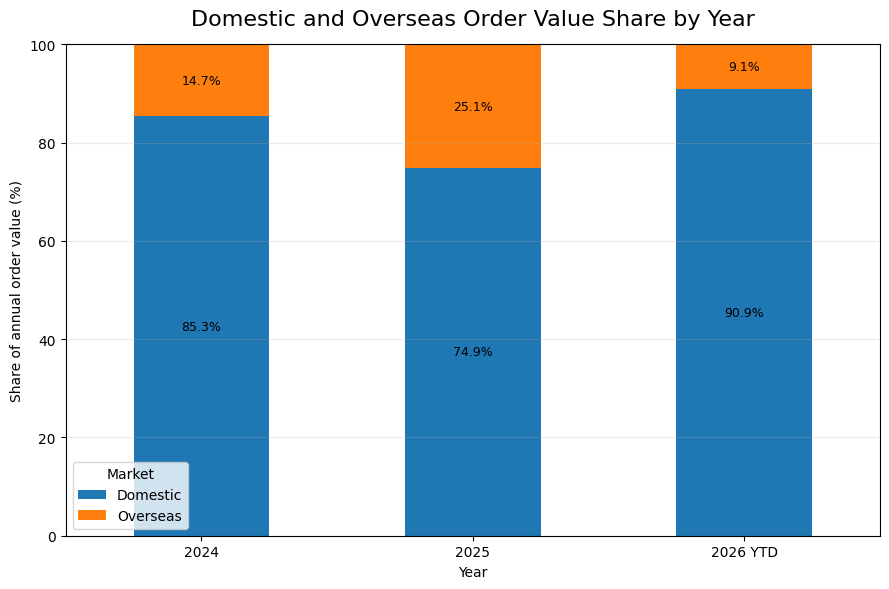


Public analytical findings:


,finding,result
0,Highest customer value index,Customer_01 (100.0)
1,Most overseas-dependent top customer,Customer_03 (100.0%)
2,Highest employee value index in 2025,Employee_01 (100.0)
3,Highest employee value index in 2026 Jan–Jun,Employee_01 (100.0)
4,Overseas share of order value in 2025,25.1%



Generated files:
- 01_top5_customer_value_index.png
- 02_top5_customer_market_mix.png
- 03_top5_customer_monthly_trend.png
- 04_employee_yearly_order_value_index.png
- 05_employee_same_period_comparison.png
- 06_market_share_by_year.png
- public_findings.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display


# ============================================================
# 1. Output folder
# ============================================================

chart_dir = "public_charts"
os.makedirs(chart_dir, exist_ok=True)

plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 2. Chart 1 — Top 5 customer value index
# ============================================================

customer_rank_chart = (
    customer_summary
    .sort_values("rank", ascending=False)
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    customer_rank_chart["customer_id"],
    customer_rank_chart["total_value_index"]
)

ax.set_title(
    "Top 5 Customers by Order Value Index",
    fontsize=16,
    pad=14
)
ax.set_xlabel("Order value index (highest customer = 100)")
ax.set_ylabel("Anonymized customer")
ax.set_xlim(0, 110)
ax.grid(axis="x", alpha=0.25)

for bar, value in zip(
    bars,
    customer_rank_chart["total_value_index"]
):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()

chart_1 = f"{chart_dir}/01_top5_customer_value_index.png"

plt.savefig(
    chart_1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. Chart 2 — Domestic / overseas share by top customer
# ============================================================

customer_mix_chart = (
    customer_summary
    .sort_values("rank")
    .set_index("customer_id")
    [
        [
            "domestic_share_pct",
            "overseas_share_pct"
        ]
    ]
    .rename(columns={
        "domestic_share_pct": "Domestic",
        "overseas_share_pct": "Overseas"
    })
)

fig, ax = plt.subplots(figsize=(11, 6))

customer_mix_chart.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Domestic and Overseas Share of Top 5 Customers",
    fontsize=16,
    pad=14
)
ax.set_xlabel("Anonymized customer")
ax.set_ylabel("Share of customer order value (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Market")

plt.tight_layout()

chart_2 = f"{chart_dir}/02_top5_customer_market_mix.png"

plt.savefig(
    chart_2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. Chart 3 — Monthly trend for top 5 customers
#    Missing customer-month combinations are filled with zero.
# ============================================================

customer_monthly_plot = customer_monthly.copy()

customer_monthly_plot["year_month"] = pd.to_datetime(
    customer_monthly_plot["year_month"],
    format="%Y-%m"
)

full_month_range = pd.date_range(
    start="2024-01-01",
    end="2026-06-01",
    freq="MS"
)

monthly_pivot = (
    customer_monthly_plot
    .pivot_table(
        index="year_month",
        columns="customer_id",
        values="monthly_value_index",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(full_month_range, fill_value=0)
    .reindex(
        columns=(
            customer_summary
            .sort_values("rank")["customer_id"]
            .tolist()
        ),
        fill_value=0
    )
)

fig, ax = plt.subplots(figsize=(15, 7))

for customer_id in monthly_pivot.columns:
    ax.plot(
        monthly_pivot.index,
        monthly_pivot[customer_id],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=customer_id
    )

ax.set_title(
    "Monthly Order Value Index for Top 5 Customers",
    fontsize=16,
    pad=14
)
ax.set_xlabel("Month")
ax.set_ylabel("Monthly order value index (largest month = 100)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(
    title="Customer",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(
    monthly_pivot.index[::2],
    [
        date.strftime("%Y-%m")
        for date in monthly_pivot.index[::2]
    ],
    rotation=45,
    ha="right"
)

plt.tight_layout(rect=[0, 0, 0.84, 1])

chart_3 = f"{chart_dir}/03_top5_customer_monthly_trend.png"

plt.savefig(
    chart_3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. Chart 4 — Employee yearly order value index
# ============================================================

employee_yearly_pivot = (
    employee_yearly
    .pivot_table(
        index="employee_id",
        columns="year_label",
        values="order_value_index",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(
        columns=["2024", "2025", "2026 YTD"],
        fill_value=0
    )
)

employee_order = (
    employee_yearly_pivot
    .max(axis=1)
    .sort_values(ascending=False)
    .index
)

employee_yearly_pivot = (
    employee_yearly_pivot
    .reindex(employee_order)
)

fig, ax = plt.subplots(
    figsize=(max(12, len(employee_yearly_pivot) * 1.1), 7)
)

employee_yearly_pivot.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Employee Order Value Index by Year",
    fontsize=16,
    pad=14
)
ax.set_xlabel("Anonymized employee")
ax.set_ylabel("Order value index (largest employee-year = 100)")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Year")

fig.text(
    0.01,
    0.01,
    "2026 includes January through June only.",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

chart_4 = f"{chart_dir}/04_employee_yearly_order_value_index.png"

plt.savefig(
    chart_4,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. Chart 5 — Employee Jan–Jun same-period comparison
# ============================================================

employee_same_period_pivot = (
    employee_same_period
    .pivot_table(
        index="employee_id",
        columns="year",
        values="order_value_index",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(
        columns=[2024, 2025, 2026],
        fill_value=0
    )
)

employee_same_order = (
    employee_same_period_pivot
    .max(axis=1)
    .sort_values(ascending=False)
    .index
)

employee_same_period_pivot = (
    employee_same_period_pivot
    .reindex(employee_same_order)
)

employee_same_period_pivot.columns = [
    "2024 Jan–Jun",
    "2025 Jan–Jun",
    "2026 Jan–Jun"
]

fig, ax = plt.subplots(
    figsize=(max(12, len(employee_same_period_pivot) * 1.1), 7)
)

employee_same_period_pivot.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Employee Order Value Index: January–June Comparison",
    fontsize=16,
    pad=14
)
ax.set_xlabel("Anonymized employee")
ax.set_ylabel("Order value index (largest same-period result = 100)")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Period")

plt.tight_layout()

chart_5 = f"{chart_dir}/05_employee_same_period_comparison.png"

plt.savefig(
    chart_5,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. Chart 6 — Domestic / overseas market share by year
# ============================================================

market_yearly_pivot = (
    market_yearly
    .pivot_table(
        index="year",
        columns="market_type",
        values="share_pct",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(
        columns=["Domestic", "Overseas"],
        fill_value=0
    )
)

market_yearly_pivot.index = [
    "2024",
    "2025",
    "2026 YTD"
]

fig, ax = plt.subplots(figsize=(9, 6))

market_yearly_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Domestic and Overseas Order Value Share by Year",
    fontsize=16,
    pad=14
)
ax.set_xlabel("Year")
ax.set_ylabel("Share of annual order value (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Market")

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 5
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

plt.tight_layout()

chart_6 = f"{chart_dir}/06_market_share_by_year.png"

plt.savefig(
    chart_6,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. Public analytical findings
# ============================================================

top_customer = (
    customer_summary
    .sort_values("rank")
    .iloc[0]
)

highest_overseas_customer = (
    customer_summary
    .sort_values(
        "overseas_share_pct",
        ascending=False
    )
    .iloc[0]
)

top_employee_2025 = (
    employee_yearly[
        employee_yearly["year"].eq(2025)
    ]
    .sort_values(
        "order_value_index",
        ascending=False
    )
    .iloc[0]
)

top_employee_same_period_2026 = (
    employee_same_period[
        employee_same_period["year"].eq(2026)
    ]
    .sort_values(
        "order_value_index",
        ascending=False
    )
    .iloc[0]
)

overseas_2025_share = (
    market_yearly.loc[
        market_yearly["year"].eq(2025)
        & market_yearly["market_type"].eq("Overseas"),
        "share_pct"
    ]
    .iloc[0]
)

findings = pd.DataFrame({
    "finding": [
        "Highest customer value index",
        "Most overseas-dependent top customer",
        "Highest employee value index in 2025",
        "Highest employee value index in 2026 Jan–Jun",
        "Overseas share of order value in 2025"
    ],
    "result": [
        (
            f"{top_customer['customer_id']} "
            f"({top_customer['total_value_index']:.1f})"
        ),
        (
            f"{highest_overseas_customer['customer_id']} "
            f"({highest_overseas_customer['overseas_share_pct']:.1f}%)"
        ),
        (
            f"{top_employee_2025['employee_id']} "
            f"({top_employee_2025['order_value_index']:.1f})"
        ),
        (
            f"{top_employee_same_period_2026['employee_id']} "
            f"({top_employee_same_period_2026['order_value_index']:.1f})"
        ),
        f"{overseas_2025_share:.1f}%"
    ]
})

findings.to_csv(
    f"{chart_dir}/public_findings.csv",
    index=False
)

print("\nPublic analytical findings:")
display(findings)


# ============================================================
# 9. Download all chart outputs as a ZIP file
# ============================================================

zip_name = shutil.make_archive(
    "public_charts",
    "zip",
    chart_dir
)

print("\nGenerated files:")

for file_name in sorted(os.listdir(chart_dir)):
    print("-", file_name)

files.download(zip_name)
